In [ ]:
import cozip
import rasterio

# Read INDEX.parquet from anywhere (local path or https URL).
df = cozip.read(
    "https://huggingface.co/datasets/Major-TOM/Core-VIIRS-Nighttime-Light/resolve/main/INDEX.parquet"
)

# Pick a patch by id (or filter by bbox, country, year, etc.).
row = df[df["id"] == "MT10_696D_231L"].iloc[0]

# `cozip:gdal_vsi` is a /vsisubfile/ path GDAL can open directly.
with rasterio.open(row["cozip:gdal_vsi"]) as src:
    arr = src.read(1)
    print(arr.shape, src.crs, src.bounds)

In [4]:
import requests
import rasterio
import pandas as pd

url = "https://huggingface.co/datasets/Major-TOM/Core-VIIRS-Nighttime-Light/resolve/main/INDEX.parquet"
df = pd.read_parquet(url)
row = df[df["id"] == "MT10_696D_231L"].iloc[0]

url = f"https://huggingface.co/datasets/Major-TOM/Core-VIIRS-Nighttime-Light/resolve/main/{row['shard']}"
off, sz = int(row["offset"]), int(row["size"])
blob = requests.get(url, headers={"Range": f"bytes={off}-{off + sz - 1}"}).content
with rasterio.io.MemoryFile(blob) as mem, mem.open() as src:
    arr = src.read(1)

In [ ]:
import rasterio

base = (
    "https://huggingface.co/datasets/Major-TOM/Core-VIIRS-Nighttime-Light/resolve/main"
)
shard = "2016/MAJORTOM-VIIRS-NTL_2016_median_000.zip"
vsi = f"/vsisubfile/1054109_198293,/vsicurl/{base}/{shard}"

with rasterio.open(vsi) as src:
    print(src.shape)  # (1056, 1056)
    print(src.res)  # (10.0, 10.0)
    print(src.crs)  # EPSG:32723

In [21]:
df

,name,offset,size,id,majortom:code_100km,majortom:code_1000km,terrain:elevation,socio:cisi,climate:precipitation,climate:temperature,...,socio:gdp,socio:human_modification,socio:population,admin:country,admin:state,admin:district,geometry,year,shard,bbox
0,MT10_696D_231L_2016_median.tif,1054109,198293,MT10_696D_231L,MT100_70D_23L,MT1000_8D_2L,0.0,0.0,0.615046,268.089417,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\xd0\x96\xab\xa4QmF\xc0-...,2016,2016/MAJORTOM-VIIRS-NTL_2016_median_000.zip,"{'xmin': -44.85405349731445, 'ymin': -62.47005..."
1,MT10_504D_394L_2016_median.tif,1252462,230147,MT10_504D_394L,MT100_51D_40L,MT1000_6D_4L,0.0,0.0,1.044643,284.459503,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\x00[\xd1\x99\xad\x1bI\x...,2016,2016/MAJORTOM-VIIRS-NTL_2016_median_000.zip,"{'xmin': -50.21623611450195, 'ymin': -45.22455..."
2,MT10_509D_392L_2016_median.tif,1482669,216153,MT10_509D_392L,MT100_52D_39L,MT1000_6D_4L,0.0,0.0,1.029992,284.123932,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\xd6Y\xd3\xab\x93/I\xc0\...,2016,2016/MAJORTOM-VIIRS-NTL_2016_median_000.zip,"{'xmin': -50.3716926574707, 'ymin': -45.673652..."
3,MT10_508D_387L_2016_median.tif,1698882,280594,MT10_508D_387L,MT100_51D_39L,MT1000_6D_4L,0.0,0.0,1.059469,284.093964,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\x8e$\xd0\xc3\xe0\xd1H\x...,2016,2016/MAJORTOM-VIIRS-NTL_2016_median_000.zip,"{'xmin': -49.639671325683594, 'ymin': -45.5838..."
4,MT10_511D_390L_2016_median.tif,1979536,221930,MT10_511D_390L,MT100_52D_39L,MT1000_6D_4L,0.0,0.0,1.031037,283.948547,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\x02\xed\xa2\xbdV#I\xc0\...,2016,2016/MAJORTOM-VIIRS-NTL_2016_median_000.zip,"{'xmin': -50.276084899902344, 'ymin': -45.8532..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2108336,MT10_434D_689R_2024_median.tif,69526005,200819,MT10_434D_689R,MT100_44D_68R,MT1000_5D_6R,0.0,0.0,0.973774,286.820526,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\xfa\x8c\xd9~:\xeaS@\xab...,2024,2024/MAJORTOM-VIIRS-NTL_2024_median_000.zip,"{'xmin': 79.65982055664062, 'ymin': -38.937126..."
2108337,MT10_421D_684R_2024_median.tif,69726884,278114,MT10_421D_684R,MT100_43D_67R,MT1000_5D_6R,0.0,0.0,0.935563,287.419983,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\r\x14\xbc\x9bSuS@oqZ\xb...,2024,2024/MAJORTOM-VIIRS-NTL_2024_median_000.zip,"{'xmin': 77.8332290649414, 'ymin': -37.7694625..."
2108338,MT10_429D_678R_2024_median.tif,70005058,280542,MT10_429D_678R,MT100_43D_67R,MT1000_5D_6R,0.0,0.0,0.941854,287.177734,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\x1c\x99\x13\xf0|zS@G\xf...,2024,2024/MAJORTOM-VIIRS-NTL_2024_median_000.zip,"{'xmin': 77.91387939453125, 'ymin': -38.488025..."
2108339,MT10_715D_644R_2024_median.tif,70285660,371814,MT10_715D_644R,MT100_72D_63R,MT1000_8D_5R,0.0,0.0,1.169068,268.190857,...,0.0,0.0,0.0,Ocean/Sea/Lakes,Ocean/Sea/Lakes,Ocean/Sea/Lakes,b'\x01\x01\x00\x00\x00\x01s?\xb0\xb0\xa3`@$\xe...,2024,2024/MAJORTOM-VIIRS-NTL_2024_median_000.zip,"{'xmin': 133.11532592773438, 'ymin': -64.17664..."


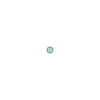

In [13]:
from shapely import wkb

row = df[df["id"] == "MT10_696D_231L"].iloc[0]
geom = wkb.loads(row.geometry)
geom

(1056, 1056)


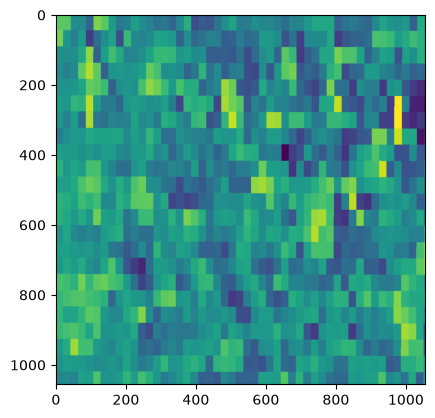

In [22]:
import matplotlib.pyplot as plt

print(arr.shape)
plt.imshow(arr)